# Imports

In [1]:
#import packages
import numpy as np
import json 
import scanpy as sc
from collections import OrderedDict
import scipy 
import pandas as pd
import matplotlib.pyplot as plt
import pickle

#spectra imports 
import Spectra 
from Spectra import Spectra_util as spc_tl
from Spectra import K_est as kst
from Spectra import default_gene_sets

/Users/mkaur/miniconda3/envs/spectra/lib/python3.10/site-packages/Spectra/Spectra_util.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
pwd

'/Users/mkaur/github/2_tff1/1_tecs/1_pyzone/0_notebooks/0_scRNA/5_spectra'

In [3]:
adata = sc.read_h5ad('/Users/mkaur/github/2_tff1/1_tecs/1_pyzone/3_h5ad/8_adata_final.h5ad')
adata

AnnData object with n_obs × n_vars = 10336 × 33594
    obs: 'sample', 'log10_original_total_counts', 'n_genes_by_counts', 'ribo_frac', 'mito_frac', 'cell_type', 'cell_type_subset'
    uns: 'cell_type_colors', 'cell_type_subset_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_data'
    obsp: 'connectivities', 'distances'

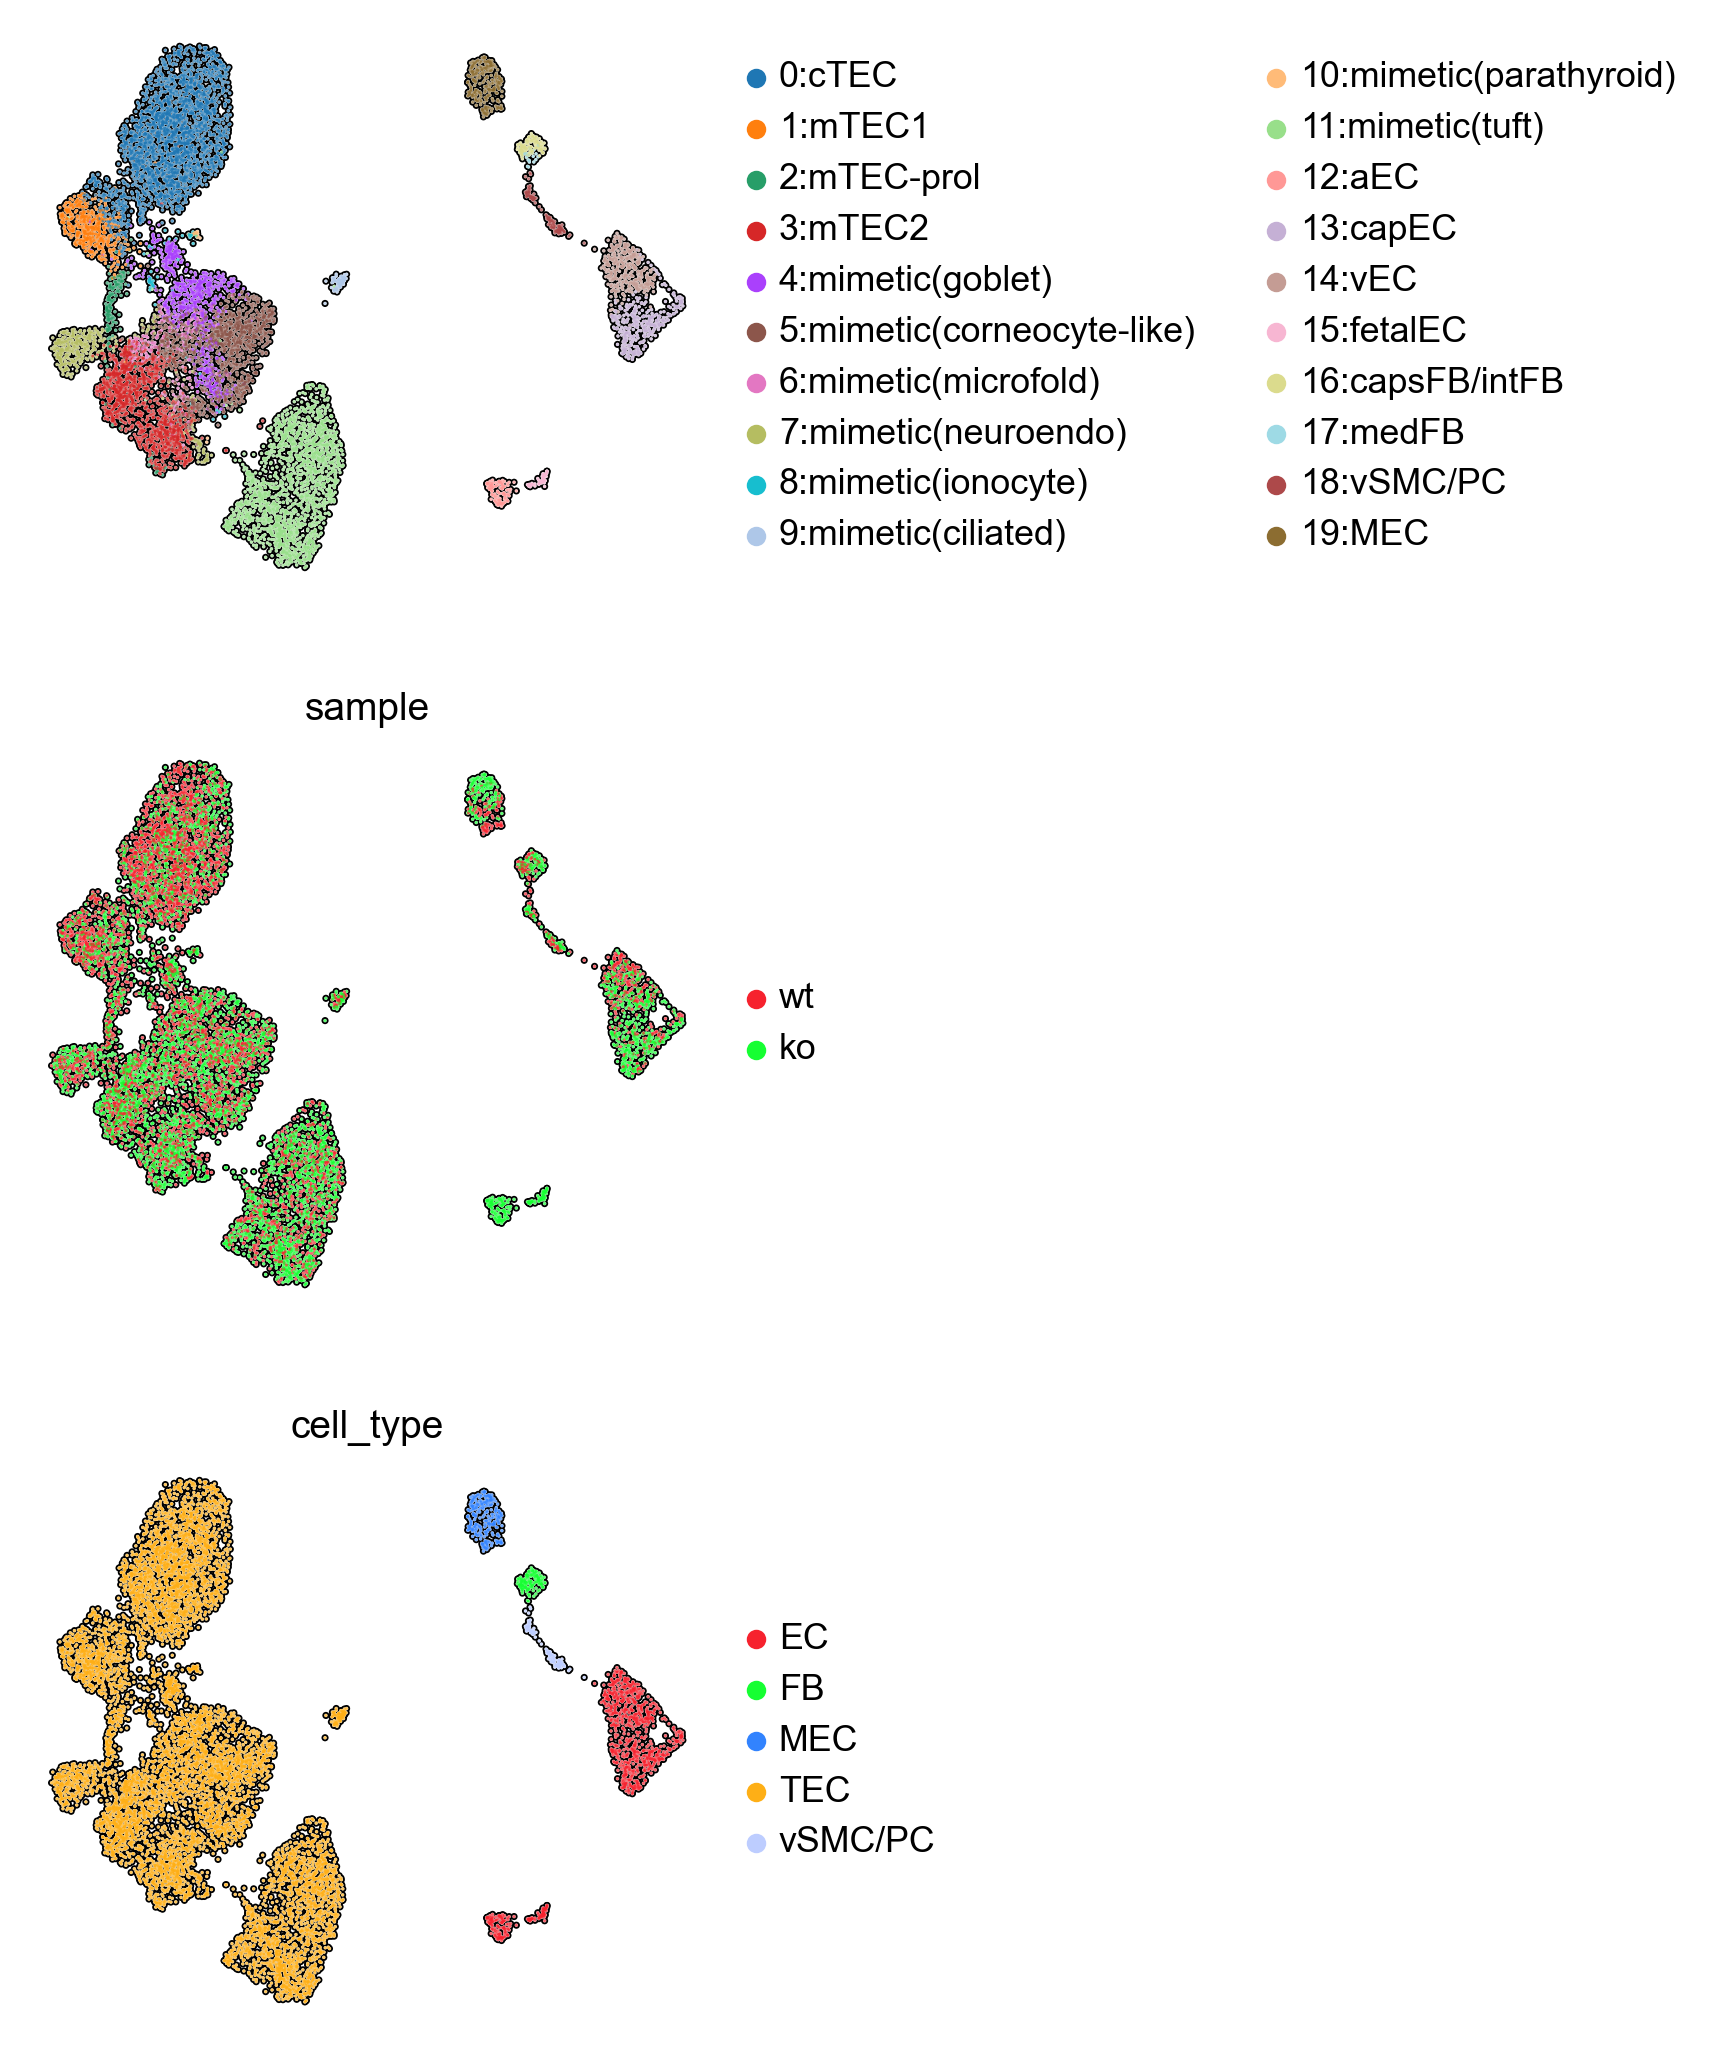

In [4]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='Spectral_r', vector_friendly=True, transparent=True)
sc.pl.umap(
    adata, 
    color=['cell_type_subset', 'sample', 'cell_type'],  
    ncols=1,
    size =5, 
    outline_width=[0.6, 0.05],
    frameon=False,
    cmap='Spectral_r',
    use_raw=False, 
    #vmax = 'p99', 
    add_outline=True,
    #legend_loc = 'on data', 
    title='',
    #save='_annotation.pdf'
)

# Set up Spectra Dict

In [6]:
adata = adata[adata.obs['sample'].isin(['wt'])].copy()
adata

AnnData object with n_obs × n_vars = 4821 × 33594
    obs: 'sample', 'log10_original_total_counts', 'n_genes_by_counts', 'ribo_frac', 'mito_frac', 'cell_type', 'cell_type_subset'
    uns: 'cell_type_colors', 'cell_type_subset_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_data'
    obsp: 'connectivities', 'distances'

In [7]:
sc.tl.rank_genes_groups(adata, groupby='cell_type_subset', method='wilcoxon', use_raw=False)
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
df = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names']}).head(100) #'scores', 'logfoldchanges', 'pvals_adj'

df.head()

,0:cTEC_n,1:mTEC1_n,2:mTEC-prol_n,3:mTEC2_n,4:mimetic(goblet)_n,5:mimetic(corneocyte-like)_n,6:mimetic(microfold)_n,7:mimetic(neuroendo)_n,8:mimetic(ionocyte)_n,9:mimetic(ciliated)_n,10:mimetic(parathyroid)_n,11:mimetic(tuft)_n,13:capEC_n,14:vEC_n,16:capsFB/intFB_n,17:medFB_n,18:vSMC/PC_n,19:MEC_n
0,Shisa2,Ccl21a,S100a2,Syt1,Anxa1,Skint3,Muc13,Rap1gap2,Cab39,Ccdc153,Kansl1l,Mctp1,Cd36,Pecam1,Postn,Gsn,Prkg1,Igfbp6
1,Tenm4,Cald1,Aire,Ubd,Gabrp,Spink5,Bcl2l15,Stxbp5l,Akap13,Spag17,Chga,Avil,Cav1,Cd93,Col6a3,Lrp1,Dlc1,Aebp1
2,Pax1,Robo1,Icosl,Fcgbp,Serpinb11,Ly6d,Cldn7,Ptprn2,Clint1,Sntn,Npnt,Ivns1abp,Sptbn1,Ly6c1,Pdgfra,Slit3,Zeb2,Csrp2
3,Mtss2,Plce1,Actn3,Myo3b,Gsto1,Dapl1,Apobec1,Fchsd2,Atp6v1c2,Cdhr3,Pth,Bmx,Ptprm,Esam,Lhfp,Svep1,Nr2f2,Rarres2
4,Cstb,Lifr,S100a3,Slc9a7,Mlph,Fam3d,Hnf4g,Syt1,Ppargc1a,Tmem212,Sycp2l,Atp2a3,Fabp4,Ldb2,Lum,Serpinf1,Gucy1b1,C3


In [8]:
N = 35  # how many markers per cell type

gene_set_dictionary = {}
for ct in groups:
    # Grab the top N names, ensure strings, drop NaNs/empties, keep unique order
    names = pd.Series(result['names'][ct]).astype(str)
    names = names.replace({'nan': np.nan}).dropna()
    # Keep order-unique
    seen = set()
    topN = [g for g in names.tolist() if (g not in seen and not seen.add(g))][:N]
    
    # One gene set per cell type
    gene_set_dictionary[ct] = {f'{ct}': topN}

In [9]:
gene_set_dictionary

{'0:cTEC': {'0:cTEC': ['Shisa2',
   'Tenm4',
   'Pax1',
   'Mtss2',
   'Cstb',
   'Tns3',
   'Ctsl',
   'Prss16',
   'Pltp',
   'Agpat3',
   'Amotl1',
   'Psat1',
   'Ly75',
   'Gas6',
   'Hexb',
   'Hey1',
   'Xrcc5',
   'Scn1a',
   'Mir100hg',
   'Il7',
   'Ndrg3',
   'Ston2',
   'Kctd1',
   'Itm2c',
   'Epb41l3',
   'Cxcl12',
   'Nlgn1',
   'Ank3',
   'Syngr1',
   'Ust',
   'Lamp2',
   'Osbpl6',
   'Krt18',
   'Ube4b',
   'Psmb11']},
 '1:mTEC1': {'1:mTEC1': ['Ccl21a',
   'Cald1',
   'Robo1',
   'Plce1',
   'Lifr',
   'Tpm2',
   'Tgfbi',
   'Xylt1',
   'Csmd1',
   'Sfrp1',
   'Eya4',
   'Macrod2',
   'Ascl1',
   '2610307P16Rik',
   'Krt14',
   'Antxr1',
   'Igdcc4',
   'Col6a1',
   'Robo2',
   'Itga6',
   'Htra1',
   'Zfp521',
   'Sdk2',
   'Kcnma1',
   'Nedd4',
   'Kazn',
   'Dpysl3',
   'Tmtc1',
   'Mdk',
   'Emp2',
   'Tenm3',
   'Tmsb10',
   'Fgfr2',
   'Wfikkn2',
   'Lama3']},
 '2:mTEC-prol': {'2:mTEC-prol': ['S100a2',
   'Aire',
   'Icosl',
   'Actn3',
   'S100a3',
   'H2-DMb2'

In [10]:
sc.tl.rank_genes_groups(adata, groupby='cell_type', method='wilcoxon', use_raw=False)
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
df = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names']}).head(100) #'scores', 'logfoldchanges', 'pvals_adj'

df.head()

,EC_n,FB_n,MEC_n,TEC_n,vSMC/PC_n
0,Ptprm,Lum,Igfbp6,Epcam,Prkg1
1,Sptbn1,Pdgfra,Aebp1,Dsp,Dlc1
2,Pecam1,Col6a3,Csrp2,Cdh1,Zeb2
3,Cdh5,Lama2,Rarres2,Spint2,Nr2f2
4,Fli1,Htra3,C3,Rbm47,Gucy1b1


In [11]:
#df['vSMC/PC_n'].head(35).to_list()

In [12]:
gene_set_dictionary['global'] = {
    'epithelial': ['Epcam',
 'Dsp',
 'Cdh1',
 'Rbm47',
 'Spint2',
 'Alcam',
 'Krt8',
 'Krt18',
 'H2-Eb1',
 'Ank3',
 'Gm15987',
 'Esrp1',
 'Spint1',
 'Patj',
 'Slc9a9',
 'H2-Ab1',
 'Map7',
 'Cd74',
 'Dsg2',
 'Cdcp1',
 'Sgpl1',
 'Tiam1',
 'H2-Aa',
 'Sorl1',
 'Eya4',
 'Pstpip2',
 'Parm1',
 'Ctnnd2',
 'Eya2',
 'Pclo',
 'Sfn',
 'Wwc1',
 'Mreg',
 'Snx29',
 'Tmem131l'],
    'fibroblast': ['Col6a3',
 'Lama2',
 'Col5a2',
 'Ank2',
 'Lhfp',
 'Col6a2',
 'Fbn1',
 'Col3a1',
 'Lum',
 'Col6a1',
 'Col1a2',
 'Ddr2',
 'Abi3bp',
 'Col1a1',
 'Bicc1',
 'Prrx1',
 'Zeb2',
 'Dlc1',
 'Bgn',
 'Dcn',
 'Apod',
 'Colec12',
 'Gsn',
 'Col5a1',
 'Col5a3',
 'Cd302',
 'Gpm6b',
 'Htra3',
 'Il1r1',
 'Pdgfra',
 'Mxra8',
 'Serpine2',
 'Enpp2',
 'Serping1',
 'Cygb'], 
    'endothelial': ['Ptprm',
 'Sptbn1',
 'Pecam1',
 'Cd36',
 'Egfl7',
 'Cdh5',
 'Adgrf5',
 'Flt1',
 'Arhgap31',
 'Adgrl4',
 'Eng',
 'Cav1',
 'Fli1',
 'Ptprb',
 'Nrp1',
 'Ly6c1',
 'Col4a1',
 'Prkch',
 'Shank3',
 'Kdr',
 'Prex2',
 'Epas1',
 'Apbb2',
 'Cavin2',
 'Esam',
 'Cyyr1',
 'Itga1',
 'S1pr1',
 'Col4a2',
 'Tcf4',
 'Emcn',
 'Ushbp1',
 'Ldb2',
 'Arhgap29',
 'Gng11'], 
    'mesothelial': ['Aebp1',
 'Csrp2',
 'Igfbp6',
 'Upk3b',
 'Dcn',
 'Rarres2',
 'C3',
 'Serping1',
 'Gpm6a',
 'Timp2',
 'Mgp',
 'Igfbp4',
 'C4b',
 'Aldh1a2',
 'Ptgis',
 'Abi1',
 'Lgals1',
 'C2',
 'Nkain4',
 'Efemp1',
 'Fbln1',
 'Pals2',
 'Wt1',
 'Rspo1',
 'Sox6',
 'Rnase4',
 'Cldn15',
 'Col1a2',
 'Upk1b',
 'Gata6',
 'Gm56730',
 'Fndc1',
 'Lrrn4',
 'Laptm4a',
 'Ccdc80'],
    'vSMC/PC':['Prkg1',
 'Zeb2',
 'Dlc1',
 'Gucy1b1',
 'Nr2f2',
 'Ednra',
 'Pde3a',
 'Plac9',
 'Sox5',
 'Sparcl1',
 'Gucy1a1',
 'Cacna1c',
 'Gjc1',
 'Pdgfrb',
 'Ndufa4l2',
 'Ebf1',
 'Lhfp',
 'Bgn',
 'Rhoj',
 'Prrx1',
 'Pde1a',
 'Mylk',
 'Gm13889',
 'Plcl1',
 'Serping1',
 'Notch3',
 'Arhgap10',
 'Ppp1r12a',
 'Rgs5',
 'Rarres2',
 'Cald1',
 'Myl9',
 'Sparc',
 'Pla2r1',
 'Lin7a']
                        }

In [13]:
#filter gene set annotation dict for genes contained in adata
annotations = Spectra.Spectra_util.check_gene_set_dictionary(adata,
                                                             gene_set_dictionary,
                                                             obs_key='cell_type_subset',
                                                             global_key='global')

Cell type labels in gene set annotation dictionary and AnnData object are identical
Your gene set annotation dictionary is now correctly formatted.


In [14]:
#adata.X = adata.X.toarray()

In [15]:
model = Spectra.est_spectra(adata=adata, 
                            gene_set_dictionary=gene_set_dictionary, 
                            use_highly_variable=False,
                            cell_type_key="cell_type_subset", 
                            use_weights=True,
                            lam=0.1, 
                            rho=0.001, 
                            use_cell_types=True,
                            n_top_vals=35,
                            label_factors=True, 
                            overlap_threshold=0.2,
                            clean_gs = True, 
                            min_gs_num = 3,
                            num_epochs=100 # For a more serious analysis, please make this 10000
                            )

Cell type labels in gene set annotation dictionary and AnnData object are identical
Your gene set annotation dictionary is now correctly formatted.


: 

In [ ]:
model.return_eta_diag()

In [ ]:
import pickle
with open('/coh_labs/mvandenbrink/users/pkaur/6_tff1/0_scRNA/1_spectra/2_outputs/0_files/tec_wt_spectra_model.pickle', 'wb') as f:
    pickle.dump(model, f, pickle.HIGHEST_PROTOCOL)

In [ ]:
adata

In [ ]:
adata.write_h5ad('/coh_labs/mvandenbrink/users/pkaur/6_tff1/0_scRNA/1_spectra/2_outputs/adata_wt_spectra.h5ad')